# Modul Praktikum

# M ISRA AL MIRAD (241061001)

## Analisis Regresi Linier, Regresi Linier Berganda, dan Evaluasi Model (MAE, MSE, RMSE)

Modul ini bertujuan untuk membantu mahasiswa memahami cara membangun model regresi linier sederhana dan regresi linier berganda serta mengevaluasi performa model menggunakan beberapa ukuran kesalahan seperti **MAE**, **MSE**, dan **RMSE**.


## Tujuan Praktikum
Setelah mengikuti praktikum ini mahasiswa mampu:

1. Memahami konsep regresi linier sederhana
2. Membangun model regresi menggunakan Python
3. Membangun model regresi linier berganda
4. Menghitung MAE, MSE, dan RMSE
5. Menginterpretasikan kinerja model


## Import Library

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

## Membaca Dataset

Dataset yang digunakan misalnya dataset harga rumah.

In [ ]:
data = pd.read_excel('/content/Depth. Nporosity. Data1.xlsx')
data.head()

,Depth,Nporosity
0,0.25,-1.37
1,0.50,-2.08
2,0.75,-1.67
3,1.00,-1.16
4,1.25,-0.24


## Informasi Dataset

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Depth      40 non-null     float64
 1   Nporosity  40 non-null     float64
dtypes: float64(2)
memory usage: 772.0 bytes


## Statistik Deskriptif

In [ ]:
data.describe()

,Depth,Nporosity
count,40.000000,40.000000
mean,5.125000,0.022250
std,2.922613,0.992111
min,0.250000,-2.080000
25%,2.687500,-0.757500
50%,5.125000,0.140000
75%,7.562500,0.742500
max,10.000000,2.350000


Dataset terdiri dari 40 baris data dengan dua kolom utama: Depth (kedalaman) dan Nporosity (porositas). Rata-rata Depth adalah 5.125 dengan sebaran Nporosity antara -2.08 hingga 2.35.

## Visualisasi Hubungan Variabel

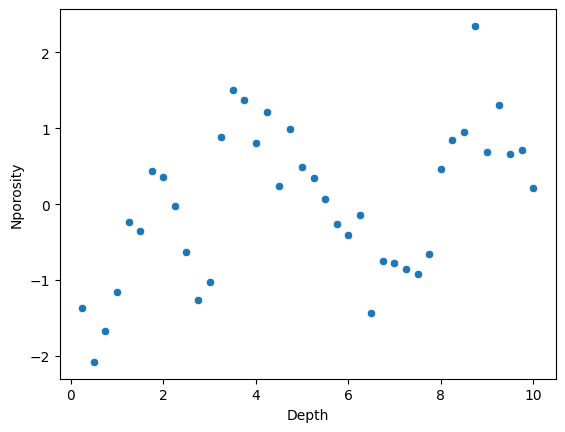

In [ ]:
sns.scatterplot(x='Depth', y='Nporosity', data=data)
plt.show()

Scatter plot menunjukkan bahwa hubungan antara Depth dan Nporosity tidak sepenuhnya linear lurus, melainkan memiliki pola fluktuasi (gelombang).

# Regresi Linier Sederhana

Model regresi:

Y = β0 + β1X + ε

## Menentukan Variabel

In [ ]:
X = data[['Depth']]
y = data['Nporosity']

## Membuat Model Regresi

In [ ]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

## Melihat Koefisien Model

In [ ]:
print('Intercept:', model.intercept_)
print('Koefisien:', model.coef_)

Intercept: -0.6919615384615387
Koefisien: [0.13935835]


 Intercept: -0.6919 (Titik potong garis pada sumbu y saat x=0).

 * Koefisien: 0.1393 (Setiap kenaikan 1 unit Depth, Nporosity diprediksi naik sebesar 0.1393).

##Membuat Visualisasi Model

In [ ]:
y_pred = model.predict(X)
print(y_pred)

[-0.65712195 -0.62228236 -0.58744278 -0.55260319 -0.5177636  -0.48292402
 -0.44808443 -0.41324484 -0.37840525 -0.34356567 -0.30872608 -0.27388649
 -0.2390469  -0.20420732 -0.16936773 -0.13452814 -0.09968856 -0.06484897
 -0.03000938  0.00483021  0.03966979  0.07450938  0.10934897  0.14418856
  0.17902814  0.21386773  0.24870732  0.2835469   0.31838649  0.35322608
  0.38806567  0.42290525  0.45774484  0.49258443  0.52742402  0.5622636
  0.59710319  0.63194278  0.66678236  0.70162195]


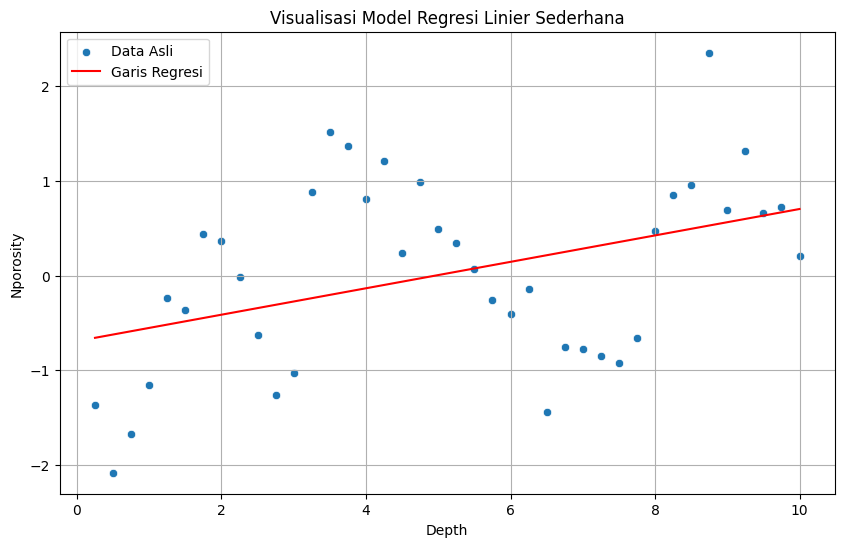

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

## Prediksi

In [ ]:
y_pred = model.predict(X)
print(y_pred)

[ 21188.4660836   24567.32054166  27946.17499971  36393.31114486
  39772.16560291  51598.15620611  53287.58343514  56666.4378932
  56666.4378932   65113.57403834  68492.4284964   70181.85572543
  70181.85572543  71871.28295445  78628.99187057  85386.70078668
  88765.55524474  92144.4097028  102280.97307697 103970.400306
 117485.81813822 122554.09982531 136069.51765754 141137.79934462
 149584.93548976 154653.21717685 163100.35332199 164789.78055102
 176615.77115422 179994.62561228]


## Mean Absolute Error (MAE) , MEan Squared Error (MSE) dan Root Mean Square Error (RMSE)

In [ ]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))


print('MAE:', mae)
print('MSE:',mse)
print('RMSE:',rmse)

MAE: 0.7399434333958724
MSE: 0.7979390086772984
RMSE: 0.8932743188278158


Model ini memiliki RMSE 0.8932. Garis merah pada grafik menunjukkan model ini terlalu sederhana karena tidak bisa mengikuti pola naik-turun data.

# Regresi Polynomial

Regresi polynomial merupakan pengembangan dari regresi linier yang digunakan untuk memodelkan hubungan nonlinier antara variabel independen dan variabel dependen. Jika hubungan antara variabel tidak dapat dijelaskan dengan garis lurus, maka regresi polynomial dapat digunakan dengan menambahkan pangkat dari variabel independen ke dalam model.

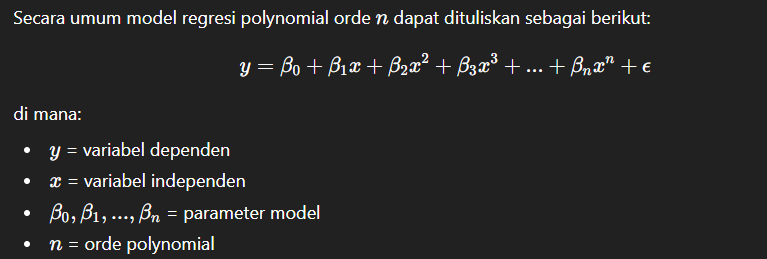


## Membuat model orde 2

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

X_poly

array([[1.00000e+00, 2.50000e-01, 6.25000e-02],
       [1.00000e+00, 5.00000e-01, 2.50000e-01],
       [1.00000e+00, 7.50000e-01, 5.62500e-01],
       [1.00000e+00, 1.00000e+00, 1.00000e+00],
       [1.00000e+00, 1.25000e+00, 1.56250e+00],
       [1.00000e+00, 1.50000e+00, 2.25000e+00],
       [1.00000e+00, 1.75000e+00, 3.06250e+00],
       [1.00000e+00, 2.00000e+00, 4.00000e+00],
       [1.00000e+00, 2.25000e+00, 5.06250e+00],
       [1.00000e+00, 2.50000e+00, 6.25000e+00],
       [1.00000e+00, 2.75000e+00, 7.56250e+00],
       [1.00000e+00, 3.00000e+00, 9.00000e+00],
       [1.00000e+00, 3.25000e+00, 1.05625e+01],
       [1.00000e+00, 3.50000e+00, 1.22500e+01],
       [1.00000e+00, 3.75000e+00, 1.40625e+01],
       [1.00000e+00, 4.00000e+00, 1.60000e+01],
       [1.00000e+00, 4.25000e+00, 1.80625e+01],
       [1.00000e+00, 4.50000e+00, 2.02500e+01],
       [1.00000e+00, 4.75000e+00, 2.25625e+01],
       [1.00000e+00, 5.00000e+00, 2.50000e+01],
       [1.00000e+00, 5.25000e+00, 2.7562

In [ ]:
#Membuat model orde 2
model2 = LinearRegression()

model2.fit(X_poly, y)

LinearRegression()

In [ ]:
y_pred2 = model2.predict(X_poly)
print(y_pred2)

[-9.52657666e-01 -8.72351045e-01 -7.94437427e-01 -7.18916810e-01
 -6.45789195e-01 -5.75054582e-01 -5.06712970e-01 -4.40764360e-01
 -3.77208752e-01 -3.16046146e-01 -2.57276541e-01 -2.00899939e-01
 -1.46916338e-01 -9.53257381e-02 -4.61281405e-02  6.76455444e-04
  4.50880496e-02  8.71066421e-02  1.26732233e-01  1.63964822e-01
  1.98804409e-01  2.31250995e-01  2.61304578e-01  2.88965160e-01
  3.14232741e-01  3.37107319e-01  3.57588896e-01  3.75677471e-01
  3.91373044e-01  4.04675616e-01  4.15585186e-01  4.24101754e-01
  4.30225321e-01  4.33955885e-01  4.35293448e-01  4.34238009e-01
  4.30789569e-01  4.24948127e-01  4.16713683e-01  4.06086237e-01]


In [ ]:
print('Intercept:', model2.intercept_)
print('Koefisien:', model2.coef_)

Intercept: -1.0353572874493948
Koefisien: [ 0.          0.33558449 -0.01914401]


In [ ]:
mae = mean_absolute_error(y, y_pred2)
mse = mean_squared_error(y, y_pred2)
rmse = np.sqrt(mean_squared_error(y, y_pred2))


print('MAE:', mae)
print('MSE:',mse)
print('RMSE:',rmse)

MAE: 0.7400630834826277
MSE: 0.7776418670853376
RMSE: 0.881840046201882


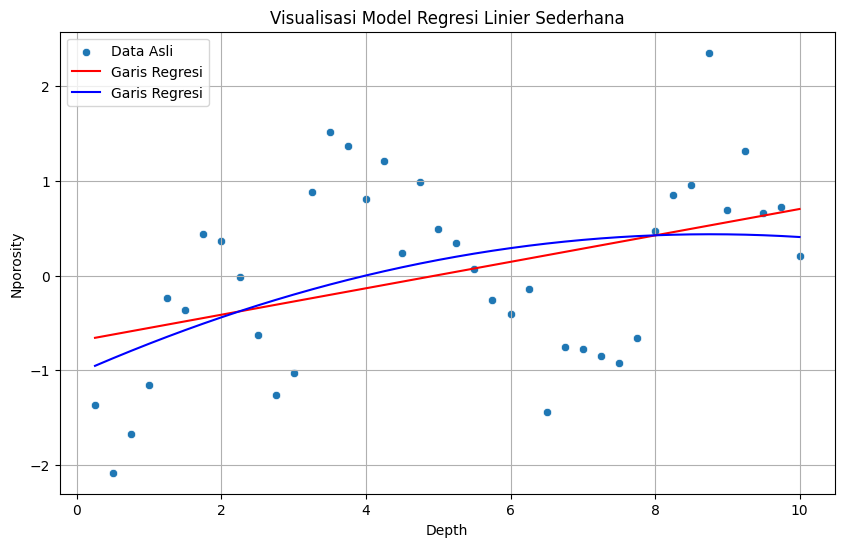

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi')
plt.plot(X, y_pred2, color='blue', label='Garis Regresi')
plt.title('Visualisasi Model Regresi Linier Sederhana')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

Model ini menggunakan persamaan $y = \beta_0 + \beta_1x + \beta_2x^2$.
* Karakteristik: Menambahkan komponen kuadratik memungkinkan model membentuk kurva parabola tunggal.
* Analisis Parameter: Memiliki intercept 1.0353 dengan koefisien fitur $x^2$ sebesar -0.0191. Nilai koefisien negatif pada $x^2$ menunjukkan kurva yang cenderung terbuka ke bawah.
* Evaluasi Error:
 MAE: 0.7400
 MSE: 0.7776
 RMSE: 0.8818
* Kesimpulan: Meskipun sudah mulai melengkung (garis biru), model ini belum mampu menangkap fluktuasi data yang lebih kompleks dan hanya memberikan sedikit peningkatan akurasi dibanding regresi linier sederhana.

## Membuat model orde 3

In [30]:
from sklearn.preprocessing import PolynomialFeatures

poly3 = PolynomialFeatures(degree=3)
X_poly3 = poly3.fit_transform(X)

model3 = LinearRegression()
model3.fit(X_poly3, y)
y_pred3 = model3.predict(X_poly3)

print('Intercept (Orde 3):', model3.intercept_)
print('Koefisien (Orde 3):', model3.coef_)

mae3 = mean_absolute_error(y, y_pred3)
mse3 = mean_squared_error(y, y_pred3)
rmse3 = np.sqrt(mean_squared_error(y, y_pred3))

print('\nMAE (Orde 3):', mae3)
print('MSE (Orde 3):', mse3)
print('RMSE (Orde 3):', rmse3)

Intercept (Orde 3): -2.415279680490101
Koefisien (Orde 3): [ 0.          1.85792331 -0.3859008   0.0238541 ]

MAE (Orde 3): 0.6199845079521994
MSE (Orde 3): 0.5761954211496901
RMSE (Orde 3): 0.7590753725090086


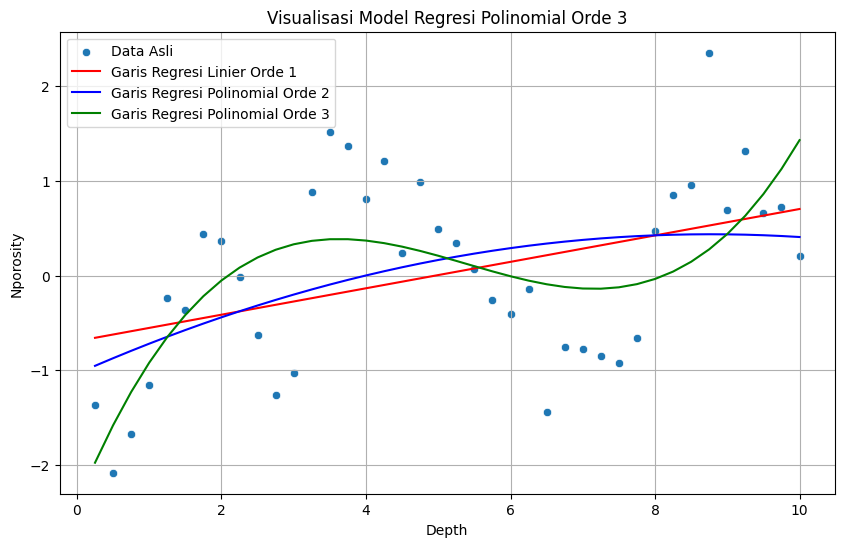

In [31]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi Linier Orde 1')
plt.plot(X, y_pred2, color='blue', label='Garis Regresi Polinomial Orde 2')
# To plot the polynomial curve smoothly, we need to sort X before plotting
sorted_zip_3 = sorted(zip(X['Depth'], y_pred3))
X_plot3, y_plot3 = zip(*sorted_zip_3)
plt.plot(X_plot3, y_plot3, color='green', label='Garis Regresi Polinomial Orde 3')
plt.title('Visualisasi Model Regresi Polinomial Orde 3')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

Model ini menggunakan persamaan $y = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3$.
* Karakteristik: Penambahan pangkat tiga memungkinkan kurva memiliki dua titik belok (infleksi), sehingga bisa membentuk pola gelombang "S".
* Analisis Parameter: Intercept meningkat signifikan menjadi 2.4152 dengan koefisien orde tertinggi ($x^3$) sebesar 0.0238.
* Evaluasi Error:MAE: 0.6199 MSE: 0.5761 RMSE: 0.7590
* Kesimpulan: Garis hijau menunjukkan performa yang jauh lebih baik dalam mengikuti pola persebaran data asli dibandingkan orde 1 dan 2. Ini adalah titik di mana model mulai benar-benar "belajar" pola non-linear pada data.

## Membuat model orde 4

In [32]:
poly4 = PolynomialFeatures(degree=4)
X_poly4 = poly4.fit_transform(X)

model4 = LinearRegression()
model4.fit(X_poly4, y)
y_pred4 = model4.predict(X_poly4)

print('Intercept (Orde 4):', model4.intercept_)
print('Koefisien (Orde 4):', model4.coef_)

mae4 = mean_absolute_error(y, y_pred4)
mse4 = mean_squared_error(y, y_pred4)
rmse4 = np.sqrt(mean_squared_error(y, y_pred4))

print('\nMAE (Orde 4):', mae4)
print('MSE (Orde 4):', mse4)
print('RMSE (Orde 4):', rmse4)

Intercept (Orde 4): -2.820283811139648
Koefisien (Orde 4): [ 0.00000000e+00  2.56942257e+00 -6.89355799e-01  6.95205274e-02
 -2.22763062e-03]

MAE (Orde 4): 0.6104172796114554
MSE (Orde 4): 0.565152739676581
RMSE (Orde 4): 0.751766412974523


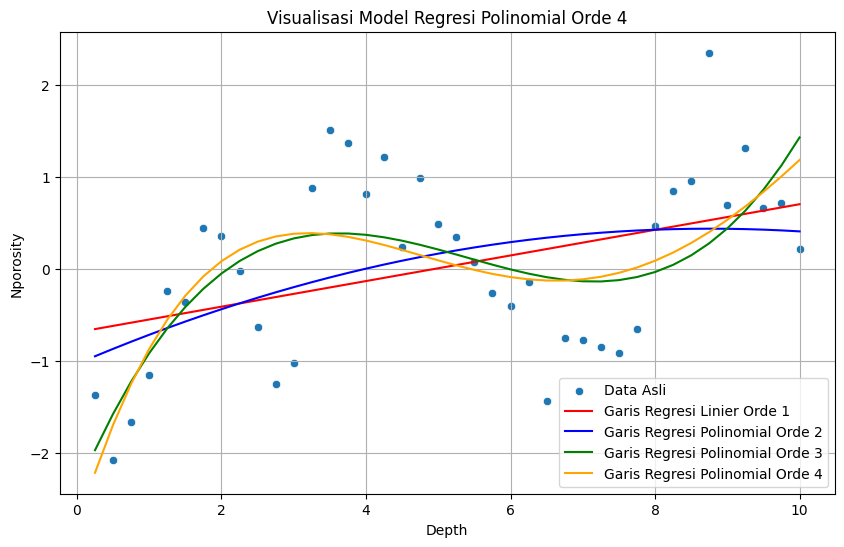

In [36]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi Linier Orde 1')
plt.plot(X, y_pred2, color='blue', label='Garis Regresi Polinomial Orde 2')
plt.plot(X_plot3, y_plot3, color='green', label='Garis Regresi Polinomial Orde 3')
# To plot the polynomial curve smoothly, we need to sort X before plotting
sorted_zip_4 = sorted(zip(X['Depth'], y_pred4))
X_plot4, y_plot4 = zip(*sorted_zip_4)
plt.plot(X_plot4, y_plot4, color='orange', label='Garis Regresi Polinomial Orde 4')
plt.title('Visualisasi Model Regresi Polinomial Orde 4')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

* Karakteristik: Memberikan fleksibilitas lebih tinggi dengan penambahan variabel $x^4$.
* Analisis Parameter: Intercept berada pada angka 2.8202. Koefisien $x^4$ bernilai sangat kecil yaitu -2.2276e-03.
* Evaluasi Error:MAE: 0.6104 MSE: 0.5651 RMSE: 0.7517
* Kesimpulan: Terjadi penurunan error, namun tidak se-drastis perubahan dari orde 2 ke orde 3. Garis oranye pada visualisasi menunjukkan model semakin merapat ke arah titik-titik data namun masih memiliki pola yang mirip dengan orde 3.

## Membuat model orde 5

In [34]:
poly5 = PolynomialFeatures(degree=5)
X_poly5 = poly5.fit_transform(X)

model5 = LinearRegression()
model5.fit(X_poly5, y)
y_pred5 = model5.predict(X_poly5)

print('Intercept (Orde 5):', model5.intercept_)
print('Koefisien (Orde 5):', model5.coef_)

mae5 = mean_absolute_error(y, y_pred5)
mse5 = mean_squared_error(y, y_pred5)
rmse5 = np.sqrt(mean_squared_error(y, y_pred5))

print('\nMAE (Orde 5):', mae5)
print('MSE (Orde 5):', mse5)
print('RMSE (Orde 5):', rmse5)

Intercept (Orde 5): -0.9237873399842297
Koefisien (Orde 5): [ 0.         -2.16243376  2.38459902 -0.71490841  0.0833085  -0.003338  ]

MAE (Orde 5): 0.4844700295770121
MSE (Orde 5): 0.4110660686255764
RMSE (Orde 5): 0.641144343050437


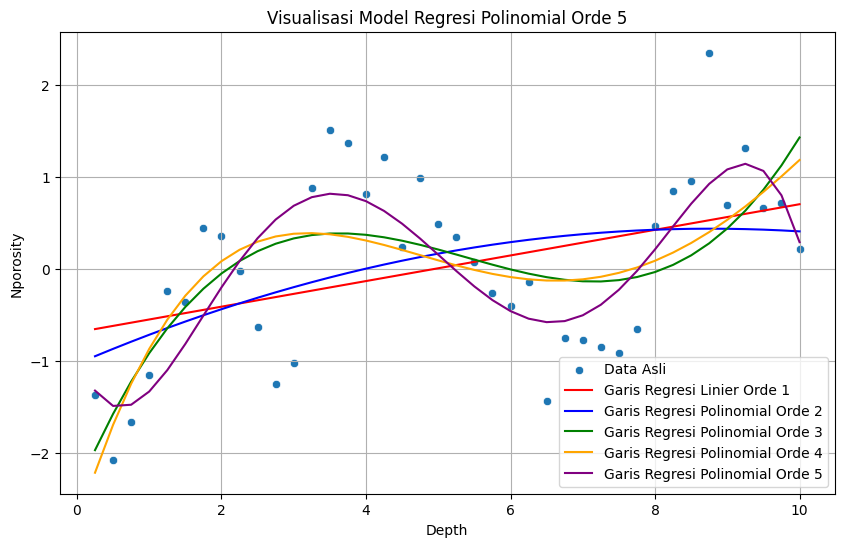

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Depth', y='Nporosity', data=data, label='Data Asli')
plt.plot(X, y_pred, color='red', label='Garis Regresi Linier Orde 1')
plt.plot(X, y_pred2, color='blue', label='Garis Regresi Polinomial Orde 2')
plt.plot(X_plot3, y_plot3, color='green', label='Garis Regresi Polinomial Orde 3')
plt.plot(X_plot4, y_plot4, color='orange', label='Garis Regresi Polinomial Orde 4')
# To plot the polynomial curve smoothly, we need to sort X before plotting
sorted_zip_5 = sorted(zip(X['Depth'], y_pred5))
X_plot5, y_plot5 = zip(*sorted_zip_5)
plt.plot(X_plot5, y_plot5, color='purple', label='Garis Regresi Polinomial Orde 5')
plt.title('Visualisasi Model Regresi Polinomial Orde 5')
plt.xlabel('Depth')
plt.ylabel('Nporosity')
plt.legend()
plt.grid(True)
plt.show()

* Karakteristik: Model paling kompleks dalam praktikum ini yang mampu menangkap detail fluktuasi terkecil.
* Analisis Parameter: Intercept berubah menjadi negatif yaitu -0.9237, menunjukkan perubahan struktur dasar garis untuk menyesuaikan dengan tren data secara keseluruhan.
* Evaluasi Error (Terbaik):MAE: 0.4844 MSE: 0.4110 RMSE: 0.6411
* Kesimpulan: Secara statistik, ini adalah model terbaik karena memiliki nilai RMSE terkecil (0.6411). Garis ungu berhasil mengikuti hampir semua gelombang mayor pada dataset, menjadikannya paling akurat untuk prediksi Nporosity berdasarkan Depth pada kasus ini.